# L-ESSFM tutorial — SNR vs transmit power

This notebook trains (or loads) an L-ESSFM digital-backpropagation model for a
chosen scenario, evaluates the **received SNR vs transmit power**, and shows the
learned **GVD step lengths** and **NLPR (Kerr) filters**.

Set `RETRAIN = False` to load saved coefficients (instant) or `True` to train.


In [1]:
import sys, os
_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(_ROOT, 'core')); os.chdir(_ROOT)
import numpy as np
import matplotlib.pyplot as plt
from system import build_system
from forward import load_or_generate
from backprop import run_methods

# ----- user settings -----
SCENARIO = 'scenario_170km_93GBd'   # or scenario_170km_186GBd / scenario_15x80km_93GBd
NS       = 10                       # DBP steps
RETRAIN  = False                    # False = load saved params; True = train from scratch
CONFIG   = f'config/{SCENARIO}.ini'
RESDIR   = f'results/{SCENARIO}'
os.makedirs(RESDIR, exist_ok=True)

S = build_system(CONFIG)
print(f"{SCENARIO}: {S['Nsp']}x{S['Lsp']/1e3:.0f}km, {S['fsym']/1e9:.0f} GBaud, "
      f"n={S['OS_d']}, forward {S['fw'].model_steps-1} steps/span")

scenario_170km_93GBd: 1x170km, 93 GBaud, n=1.125, forward 800 steps/span


## 1. Forward propagation (cached)
Generate the received signal once (slow) or load the cached copy.

In [2]:
Pgrid = np.arange(7.0, 12.1, 0.5)   # transmit power sweep [dBm]
NREAL = 3
fwd_path = f'{RESDIR}/forward.npz'
data = load_or_generate(fwd_path, S, Pgrid, NREAL)


no cache at results/scenario_170km_93GBd/forward.npz; generating forward ...
  P=7.00 dBm: 3 realizations
  P=7.50 dBm: 3 realizations
  P=8.00 dBm: 3 realizations
  P=8.50 dBm: 3 realizations
  P=9.00 dBm: 3 realizations
  P=9.50 dBm: 3 realizations
  P=10.00 dBm: 3 realizations
  P=10.50 dBm: 3 realizations
  P=11.00 dBm: 3 realizations
  P=11.50 dBm: 3 realizations
  P=12.00 dBm: 3 realizations
saved results/scenario_170km_93GBd/forward.npz  (33 signals, 919 MB)


## 2. Train or load the L-ESSFM model
Training calls `core/lessfm.py`; loading reads the saved `parameters.csv`.


In [3]:
params_path = f'{RESDIR}/lessfm_Ns{NS}/parameters.csv'
if RETRAIN or not os.path.exists(params_path):
    import subprocess, glob, re, shutil
    # build a TRAINING config from the scenario:
    #  - Gaussian symbols, short block (training data)
    #  - steps per span = NS  (anchored ^ so 'forward steps per span' is untouched)
    #  - nl alpha = 15 for training (gives the NLPR-filter Variable enough scale for
    #    Adam to refine it; any value >=5 works. The SAVED filter is physical, so the
    #    scenario/test config keeps nl alpha = 1.)
    train_cfg = f'{RESDIR}/_train_Ns{NS}.ini'
    txt = open(CONFIG).read()
    txt = txt.replace('modulation = 64-QAM', 'modulation = Gaussian')
    txt = re.sub(r'data symbols per block = \d+', 'data symbols per block = 1024', txt)
    txt = re.sub(r'(?m)^steps per span = .*', f'steps per span = {NS}', txt)
    txt = re.sub(r'(?m)^nl alpha = .*', 'nl alpha = 15.0', txt)
    open(train_cfg, 'w').write(txt)
    print('training... (this is the slow part)')
    subprocess.run(['python3', 'core/lessfm.py', '[7]', '0.002', '15000',
                    f'--config_path={train_cfg}', f'--logdir={RESDIR}/lessfm_Ns{NS}_log'],
                   check=True)
    p = sorted(glob.glob(f'{RESDIR}/lessfm_Ns{NS}_log/P*/**/parameters.csv', recursive=True))[-1]
    os.makedirs(os.path.dirname(params_path), exist_ok=True)
    shutil.copy(p, params_path)
print('using params:', params_path)


using params: results/scenario_170km_93GBd/lessfm_Ns10/parameters.csv


## 3. SNR vs transmit power
Evaluate EDC, ideal DBP and the L-ESSFM model on the same cached forward.

edc      Ns=1: peak 17.7955 dB @ 9.00 dBm
ideal    Ns=800: peak 18.4540 dB @ 9.50 dBm
lessfm   Ns=10: peak 18.5066 dB @ 9.50 dBm


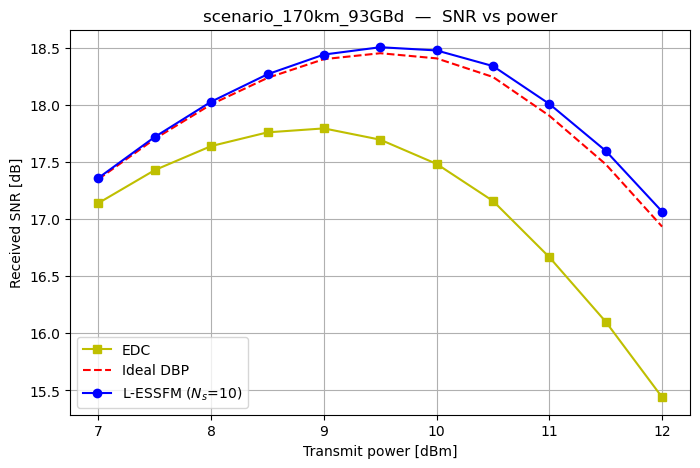

In [4]:
methods = ['edc', 'ideal:800', f'lessfm:{params_path}:{NS}']
res = run_methods(S, data, Pgrid, methods)

plt.figure(figsize=(8,5))
plt.plot(Pgrid, res['edc'], 'y-s', label='EDC')
plt.plot(Pgrid, res['ideal:800'], 'r--', label='Ideal DBP')
plt.plot(Pgrid, res[f'lessfm:{params_path}:{NS}'], 'b-o', label=f'L-ESSFM ($N_s$={NS})')
plt.xlabel('Transmit power [dBm]'); plt.ylabel('Received SNR [dB]')
plt.title(f'{SCENARIO}  —  SNR vs power'); plt.grid(True); plt.legend(); plt.show()


## 4. Next
For the **learned GVD step lengths**, the **NLPR filters**, and how the
equivalent-GVD-length profile evolves with the number of steps (JLT Fig. 1/2),
see the dedicated notebook **`04_gvd_figures.ipynb`** (same scenario).
